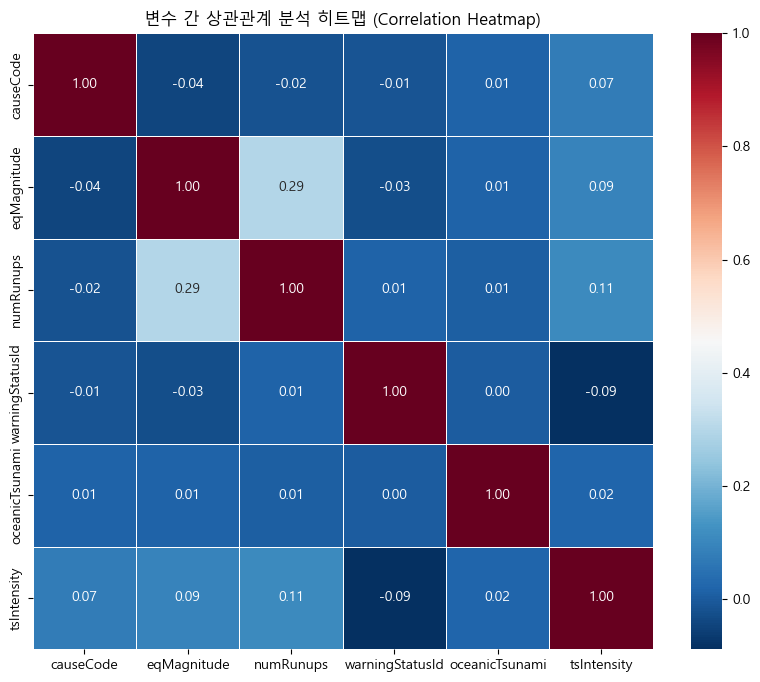

회귀 모델 성능 비교 분석 시작 (R2 Score 기준)...
------------------------------------------------------------
 Random Forest        | R2 Score: 0.0609
 Linear Regression    | R2 Score: 0.0121
 Decision Tree        | R2 Score: -0.1291
 SVR (RBF)            | R2 Score: 0.0296
 SVR (Linear)         | R2 Score: 0.0138
------------------------------------------------------------
최종 선정 모델: Random Forest


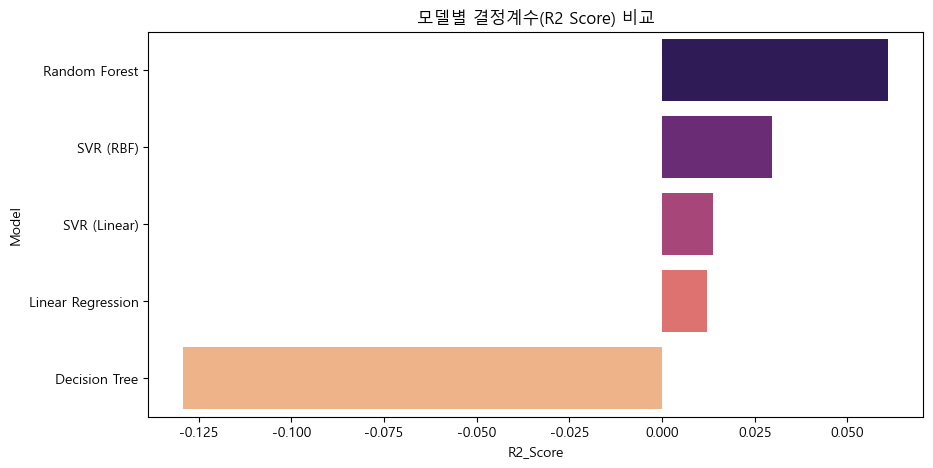

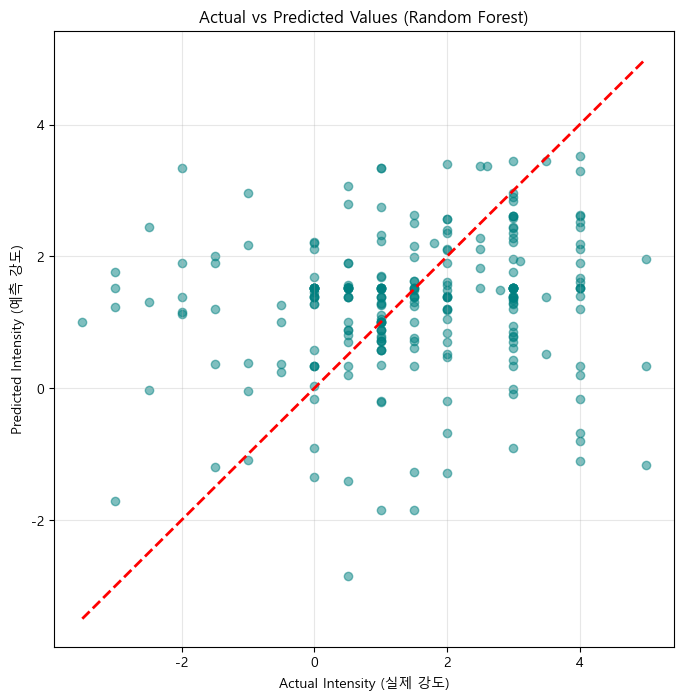

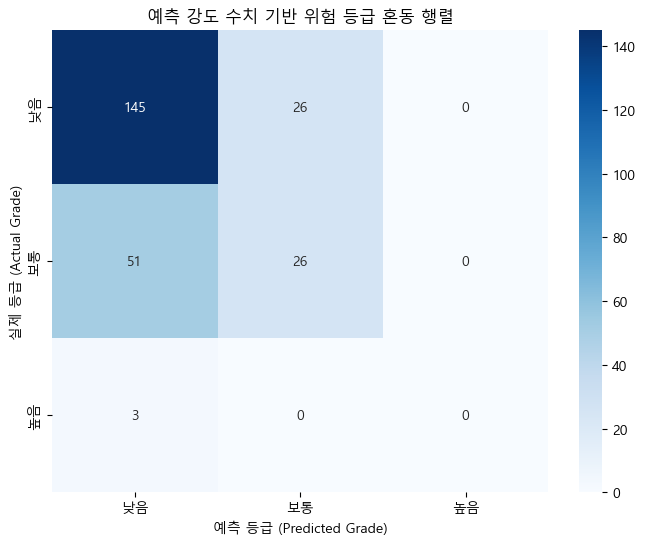

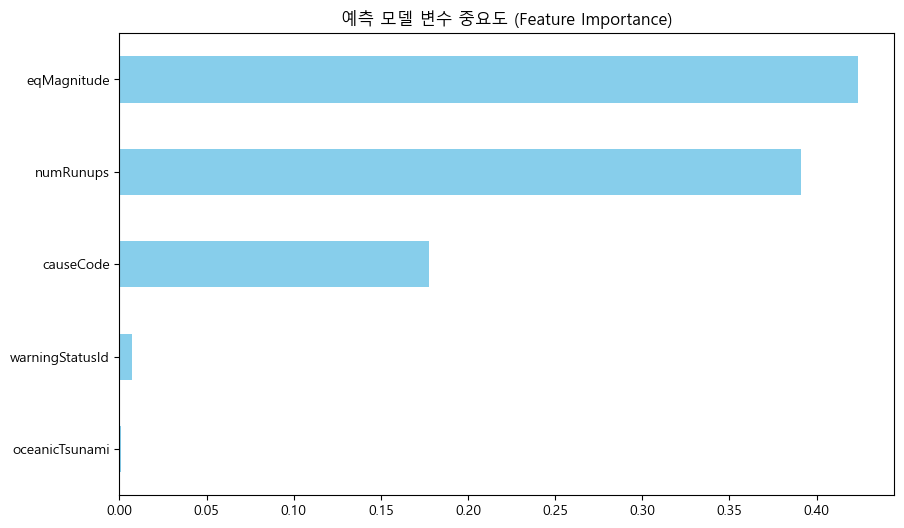


최적 회귀 모델(Random Forest) 저장 완료.


In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

# --- [0. 한글 폰트 및 환경 설정] ---
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

if not os.path.exists('model'):
    os.makedirs('model')

# --- [1. 데이터 로드 및 전처리] ---
df = pd.read_csv('dataset/Tsunami.csv')
# causeCode
# eqMagnitude : 지진의 경우 지진 규모, 화산의 경우 화산 폭발력, 산사태의 경우 산사태 규모
# numRunups : 관측된 쓰나미 런업 수
# warningStatusId : 0=없음, 1=발령, 2=해제
# oceanicTsunami : 0=육상 쓰나미, 1=해양 쓰나미
# tsIntensity : 쓰나미 강도 (0~10 사이의 연속형 수치)
cols = ['causeCode', 'eqMagnitude', 'numRunups', 'warningStatusId', 'oceanicTsunami', 'tsIntensity']
# 강도를 변환하지 않고 그대로 사용 (dropna만 수행)
data = df[cols].dropna(subset=['tsIntensity']).copy()

data['eqMagnitude'] = data['eqMagnitude'].fillna(data['eqMagnitude'].median())
data['numRunups'] = data['numRunups'].fillna(0)
data['warningStatusId'] = data['warningStatusId'].fillna(0)
data['oceanicTsunami'] = data['oceanicTsunami'].astype(float)

# --- [1.1 데이터 상관관계 분석 (추가)] ---
plt.figure(figsize=(10, 8))

# 숫자형 데이터에 대해서만 상관계수 산출
corr_matrix = data.corr()

# 히트맵 그리기
# cmap='RdBu_r': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 표현
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)

plt.title('변수 간 상관관계 분석 히트맵 (Correlation Heatmap)')
plt.show()

# 피처(X)와 타겟(y) 분리 (타겟은 연속형 수치인 tsIntensity)
X = data.drop(['tsIntensity'], axis=1)
y = data['tsIntensity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- [2. 모델별 성능 비교 (회귀 지표 사용)] ---
print("회귀 모델 성능 비교 분석 시작 (R2 Score 기준)...")
print("-" * 60)

# 회귀용 모델들로 구성
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR (RBF)": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "SVR (Linear)": SVR(kernel='linear', C=1.0, epsilon=0.1)
}

results = {}
for name, model_obj in models.items():
    # 회귀 모델이므로 scoring을 'r2'로 설정
    cv_scores = cross_val_score(model_obj, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_score = cv_scores.mean()
    results[name] = mean_score
    print(f" {name:20} | R2 Score: {mean_score:.4f}")

# 최적 모델 선정
best_model_name = max(results, key=results.get)
print("-" * 60)
print(f"최종 선정 모델: {best_model_name}")

model = models[best_model_name]

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# --- [3. 시각화 모듈 (샘플 PDF 스타일)] ---

# (1) 모델별 R2 Score 비교 (PAGE 6 스타일)
res_df = pd.DataFrame(list(results.items()), columns=['Model', 'R2_Score']).sort_values(by='R2_Score', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R2_Score', y='Model', data=res_df, hue='Model', palette='magma', legend=False)
plt.title('모델별 결정계수(R2 Score) 비교')
plt.show()

# (2) Actual vs Predicted Values 분포도 (PAGE 8 스타일)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
# 대각선 가이드라인
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted Values ({best_model_name})')
plt.xlabel('Actual Intensity (실제 강도)')
plt.ylabel('Predicted Intensity (예측 강도)')
plt.grid(True, alpha=0.3)
plt.show()

# 1. 실제값(y_test)과 예측값(y_pred)을 다시 등급(0, 1, 2)으로 변환
# (이전의 기준: 2 이하 낮음, 4 이하 보통, 4 초과 높음)
def to_grade(x):
    if x <= 2: return 0
    elif x <= 4: return 1
    else: return 2

y_test_grade = [to_grade(i) for i in y_test]
y_pred_grade = [to_grade(i) for i in y_pred]

# 2. 혼동 행렬 생성
cm = confusion_matrix(y_test_grade, y_pred_grade)

# 3. 시각화 (PAGE 6 스타일)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['낮음', '보통', '높음'], 
            yticklabels=['낮음', '보통', '높음'])

plt.title('예측 강도 수치 기반 위험 등급 혼동 행렬')
plt.xlabel('예측 등급 (Predicted Grade)')
plt.ylabel('실제 등급 (Actual Grade)')
plt.show()

# (3) 변수 중요도 (Random Forest 등 트리 모델인 경우)
if hasattr(model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', color='skyblue')
    plt.title('예측 모델 변수 중요도 (Feature Importance)')
    plt.show()

# --- [4. 모델 저장] ---
joblib.dump(model, f"model/Tsunami_reg_best_model.pkl")
joblib.dump(scaler, "model/Tsunami_scaler.pkl")
print(f"\n최적 회귀 모델({best_model_name}) 저장 완료.")